In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Load Dataset
try:
    from google.colab import files
    print("Please upload your Indian Agriculture CSV file:")
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(file_name)
except ImportError:
    df = pd.read_csv("india_agriculture_dataset.csv")

# Standardize column names (strip leading/trailing whitespace)
df.columns = df.columns.str.strip()
print(f"Dataset shape: {df.shape}")
df.head()

Please upload your Indian Agriculture CSV file:


Saving ICRISAT-District Level Data.csv to ICRISAT-District Level Data.csv
Dataset shape: (16146, 80)


,Dist Code,Year,State Code,State Name,Dist Name,RICE AREA (1000 ha),RICE PRODUCTION (1000 tons),RICE YIELD (Kg per ha),WHEAT AREA (1000 ha),WHEAT PRODUCTION (1000 tons),...,SUGARCANE YIELD (Kg per ha),COTTON AREA (1000 ha),COTTON PRODUCTION (1000 tons),COTTON YIELD (Kg per ha),FRUITS AREA (1000 ha),VEGETABLES AREA (1000 ha),FRUITS AND VEGETABLES AREA (1000 ha),POTATOES AREA (1000 ha),ONION AREA (1000 ha),FODDER AREA (1000 ha)
0,1,1966,14,Chhattisgarh,Durg,548.0,185.0,337.59,44.0,20.0,...,1777.78,0.0,0.0,0.0,5.95,6.64,12.59,0.01,0.60,0.47
1,1,1967,14,Chhattisgarh,Durg,547.0,409.0,747.71,50.0,26.0,...,1500.00,0.0,0.0,0.0,5.77,7.24,13.02,0.01,0.56,1.23
2,1,1968,14,Chhattisgarh,Durg,556.3,468.0,841.27,53.7,30.0,...,1000.00,0.0,0.0,0.0,5.41,7.40,12.81,0.10,0.58,1.02
3,1,1969,14,Chhattisgarh,Durg,563.4,400.8,711.40,49.4,26.5,...,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.6,473.6,828.55,44.2,29.0,...,2000.00,0.0,0.0,0.0,5.45,7.19,12.64,0.02,0.52,0.42


In [3]:
# Aggregate average national yields for primary staple crops over time
yield_trends = df.groupby('Year')[['RICE YIELD (Kg per ha)', 'WHEAT YIELD (Kg per ha)', 'MAIZE YIELD (Kg per ha)']].mean().reset_index()

fig_line = px.line(
    yield_trends,
    x='Year',
    y=['RICE YIELD (Kg per ha)', 'WHEAT YIELD (Kg per ha)', 'MAIZE YIELD (Kg per ha)'],
    markers=True,
    title='National Average Crop Yield Trends Over Time (Kg/ha)',
    labels={'value': 'Yield (Kg per ha)', 'variable': 'Crop'}
)
fig_line.show()

In [4]:
# Aggregate total rice and wheat production by State
state_prod = df.groupby('State Name')[['RICE PRODUCTION (1000 tons)', 'WHEAT PRODUCTION (1000 tons)']].sum().reset_index()
state_prod['TOTAL STAPLE PRODUCTION'] = state_prod['RICE PRODUCTION (1000 tons)'] + state_prod['WHEAT PRODUCTION (1000 tons)']
top_states = state_prod.sort_values(by='TOTAL STAPLE PRODUCTION', ascending=False).head(10)

fig_bar = px.bar(
    top_states,
    x='TOTAL STAPLE PRODUCTION',
    y='State Name',
    orientation='h',
    color='TOTAL STAPLE PRODUCTION',
    color_continuous_scale='Greens',
    title='Top 10 States by Combined Rice & Wheat Production (1000 tons)',
    labels={'TOTAL STAPLE PRODUCTION': 'Production (1000 tons)', 'State Name': 'State'}
)
fig_bar.show()

In [5]:
# Crop cultivation efficiency mapping for Groundnut, Sugarcane, and Cotton
recent_year = df['Year'].max()
df_recent = df[df['Year'] == recent_year].copy()

fig_bubble = px.scatter(
    df_recent,
    x='COTTON AREA (1000 ha)',
    y='COTTON PRODUCTION (1000 tons)',
    size='COTTON YIELD (Kg per ha)',
    color='State Name',
    hover_data=['Dist Name'],
    title=f'Cotton Cultivation Efficiency by District ({recent_year})',
    labels={'COTTON AREA (1000 ha)': 'Cultivated Area (1000 ha)', 'COTTON PRODUCTION (1000 tons)': 'Total Production (1000 tons)'}
)
fig_bubble.show()

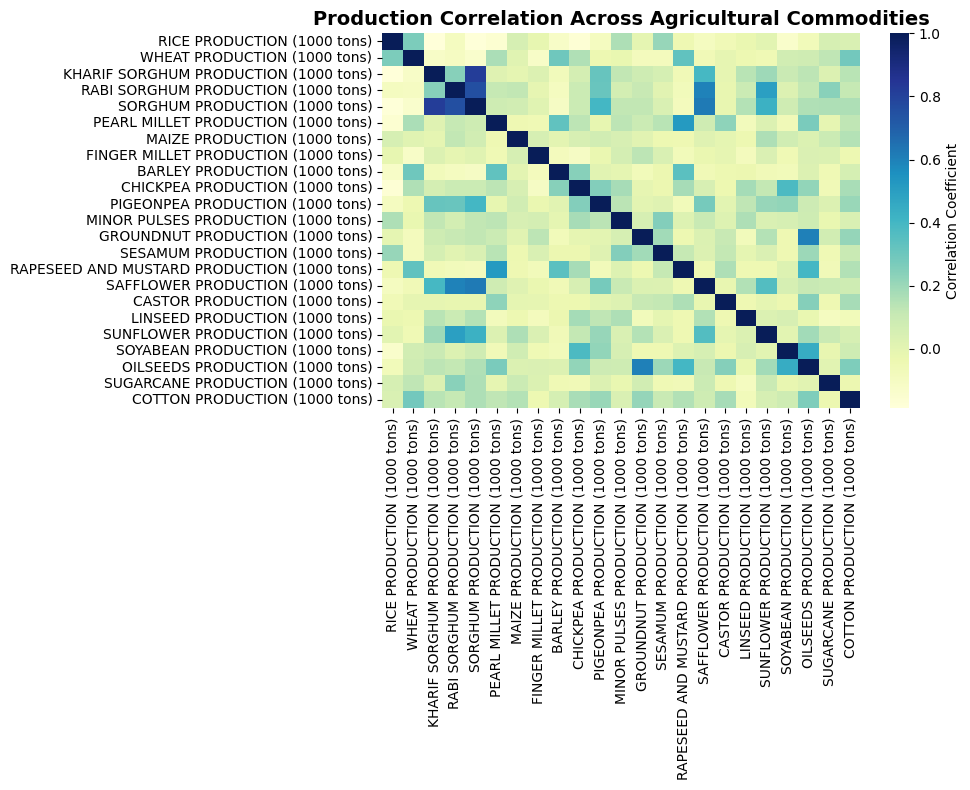

In [6]:
plt.figure(figsize=(10, 8))
crop_cols = [col for col in df.columns if 'PRODUCTION' in col]
corr_matrix = df[crop_cols].corr()

sns.heatmap(corr_matrix, annot=False, cmap='YlGnBu', cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Production Correlation Across Agricultural Commodities', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Filter out missing, zero, and negative area values
df_treemap_clean = df_area_melted[df_area_melted['Area_ha'] > 0].copy()

fig_treemap = px.treemap(
    df_treemap_clean,
    path=['State Name', 'Dist Name', 'Crop'],
    values='Area_ha',
    title=f'Hierarchical Land Allocation Breakdown (State → District → Crop) [{recent_year}]',
    color='Area_ha',
    color_continuous_scale='YlGn'
)
fig_treemap.show()

In [9]:
# ==========================================
# CELL 10: RADAR CHART (State Yield Profile Benchmarking)
# ==========================================
major_crops_yield = [
    'RICE YIELD (Kg per ha)', 'WHEAT YIELD (Kg per ha)',
    'MAIZE YIELD (Kg per ha)', 'GROUNDNUT YIELD (Kg per ha)',
    'COTTON YIELD (Kg per ha)'
]

# Pick top 3 states by overall coverage for comparative benchmarking
top_states_sample = df.groupby('State Name')['RICE PRODUCTION (1000 tons)'].sum().nlargest(3).index
df_radar = df[df['State Name'].isin(top_states_sample) & (df['Year'] == recent_year)].groupby('State Name')[major_crops_yield].mean().reset_index()

fig_radar = go.Figure()
categories = [c.replace(' YIELD (Kg per ha)', '') for c in major_crops_yield]

for _, row in df_radar.iterrows():
    fig_radar.add_trace(go.Scatterpolar(
        r=row[major_crops_yield].values,
        theta=categories,
        fill='toself',
        name=row['State Name']
    ))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True)),
    title=f'Agricultural Yield Profile Radar Comparison Across Key States [{recent_year}]',
    showlegend=True
)
fig_radar.show()

In [10]:
# ==========================================
# CELL 9: STACKED AREA CHART (Macro Cropping Shift)
# ==========================================
# Aggregate broad crop category totals over time
df['PULSES_AREA'] = df['CHICKPEA AREA (1000 ha)'] + df['PIGEONPEA AREA (1000 ha)'] + df['MINOR PULSES AREA (1000 ha)']
df['CEREALS_AREA'] = df['RICE AREA (1000 ha)'] + df['WHEAT AREA (1000 ha)'] + df['MAIZE AREA (1000 ha)']
df['OILSEEDS_TOTAL_AREA'] = df['OILSEEDS AREA (1000 ha)']

crop_time_trends = df.groupby('Year')[['CEREALS_AREA', 'PULSES_AREA', 'OILSEEDS_TOTAL_AREA', 'COTTON AREA (1000 ha)']].sum().reset_index()

fig_stacked_area = px.area(
    crop_time_trends,
    x='Year',
    y=['CEREALS_AREA', 'PULSES_AREA', 'OILSEEDS_TOTAL_AREA', 'COTTON AREA (1000 ha)'],
    title='Macro Structural Shift in Cultivated Land Allocation (1000 ha) Over Time',
    labels={'value': 'Total Cultivated Area (1000 ha)', 'variable': 'Crop Category'},
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig_stacked_area.show()

/tmp/ipykernel_820/3970695573.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




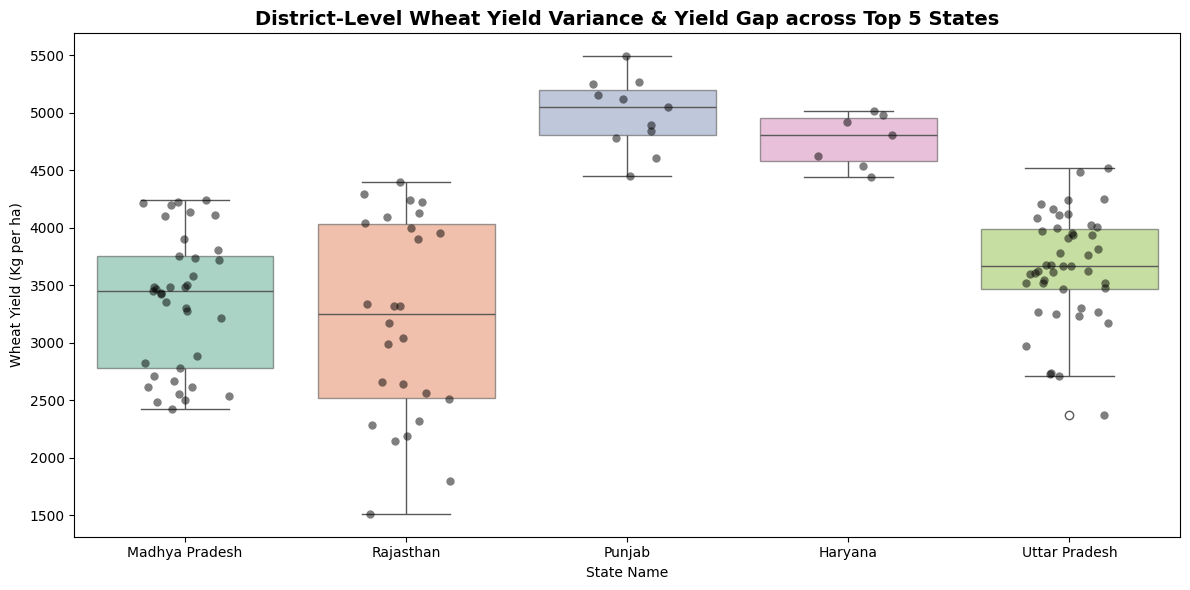

In [11]:
# ==========================================
# CELL 8: BOX PLOT WITH STRIP OVERLAY (District Yield Disparity)
# ==========================================
plt.figure(figsize=(12, 6))

# Filter top 5 wheat-producing states in the most recent year
top_5_wheat_states = df.groupby('State Name')['WHEAT PRODUCTION (1000 tons)'].sum().nlargest(5).index
df_top_wheat = df[(df['State Name'].isin(top_5_wheat_states)) & (df['Year'] == recent_year)]

sns.boxplot(
    data=df_top_wheat,
    x='State Name',
    y='WHEAT YIELD (Kg per ha)',
    palette='Set2',
    boxprops=dict(alpha=0.6)
)
sns.stripplot(
    data=df_top_wheat,
    x='State Name',
    y='WHEAT YIELD (Kg per ha)',
    color='black',
    alpha=0.5,
    jitter=0.2,
    size=6
)

plt.title('District-Level Wheat Yield Variance & Yield Gap across Top 5 States', fontsize=14, fontweight='bold')
plt.xlabel('State Name')
plt.ylabel('Wheat Yield (Kg per ha)')
plt.tight_layout()
plt.show()

In [13]:
# CELL 7 (FIXED): SUNBURST CHART
df_sorghum = df_recent.melt(
    id_vars=['State Name'],
    value_vars=['KHARIF SORGHUM PRODUCTION (1000 tons)', 'RABI SORGHUM PRODUCTION (1000 tons)'],
    var_name='Season',
    value_name='Production'
)
df_sorghum['Season'] = df_sorghum['Season'].str.replace(' SORGHUM PRODUCTION (1000 tons)', '')

# Filter out 0s and NaNs to prevent zero-weight division in Plotly hierarchy calculations
df_sorghum_clean = df_sorghum[df_sorghum['Production'] > 0].dropna().copy()

fig_sunburst = px.sunburst(
    df_sorghum_clean,
    path=['Season', 'State Name'],
    values='Production',
    color='Production',
    color_continuous_scale='Oranges',
    title='Seasonal Sorghum Production Share (Kharif vs. Rabi)'
)
fig_sunburst.show()

In [14]:
# ==========================================
# CELL 11: PCA STATE SIMILARITY CLUSTER MAP
# ==========================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Define major crop production features for multi-state comparison
prod_cols = [
    'RICE PRODUCTION (1000 tons)', 'WHEAT PRODUCTION (1000 tons)',
    'MAIZE PRODUCTION (1000 tons)', 'CHICKPEA PRODUCTION (1000 tons)',
    'GROUNDNUT PRODUCTION (1000 tons)', 'SOYABEAN PRODUCTION (1000 tons)',
    'SUGARCANE PRODUCTION (1000 tons)', 'COTTON PRODUCTION (1000 tons)'
]

# Aggregate 5-year average production per state to smooth out annual weather anomalies
recent_5_yrs = df['Year'].max() - 5
state_profiles = df[df['Year'] >= recent_5_yrs].groupby('State Name')[prod_cols].mean().fillna(0)

# Standardize feature scales & run Principal Component Analysis
scaler = StandardScaler()
scaled_data = scaler.fit_transform(state_profiles)

pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_data)

# Create PCA DataFrame for visualization
pca_df = pd.DataFrame(pca_results, columns=['PC1 (Production Volume & Scale)', 'PC2 (Crop Specialization Mix)'])
pca_df['State Name'] = state_profiles.index

fig_pca = px.scatter(
    pca_df,
    x='PC1 (Production Volume & Scale)',
    y='PC2 (Crop Specialization Mix)',
    text='State Name',
    color='PC2 (Crop Specialization Mix)',
    color_continuous_scale='Viridis',
    title='State Agricultural Relationship Map: Multi-Crop Portfolio Clustering (PCA)',
    labels={
        'PC1 (Production Volume & Scale)': 'PC1: Overall Production Scale',
        'PC2 (Crop Specialization Mix)': 'PC2: Crop Portfolio Divergence'
    }
)

fig_pca.update_traces(textposition='top center', marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')))
fig_pca.update_layout(height=600, showlegend=False)
fig_pca.show()

In [15]:
# ==========================================
# CELL 12: SANKEY DIAGRAM (State-to-Commodity Production Flow)
# ==========================================
recent_year = df['Year'].max()
df_sankey_base = df[df['Year'] == recent_year].copy()

# Group crops into macro commodity categories
df_sankey_base['Cereals'] = df_sankey_base['RICE PRODUCTION (1000 tons)'] + df_sankey_base['WHEAT PRODUCTION (1000 tons)'] + df_sankey_base['MAIZE PRODUCTION (1000 tons)']
df_sankey_base['Pulses'] = df_sankey_base['CHICKPEA PRODUCTION (1000 tons)'] + df_sankey_base['PIGEONPEA PRODUCTION (1000 tons)']
df_sankey_base['Oilseeds'] = df_sankey_base['GROUNDNUT PRODUCTION (1000 tons)'] + df_sankey_base['SOYABEAN PRODUCTION (1000 tons)'] + df_sankey_base['RAPESEED AND MUSTARD PRODUCTION (1000 tons)']
df_sankey_base['Cash Crops'] = df_sankey_base['COTTON PRODUCTION (1000 tons)'] + df_sankey_base['SUGARCANE PRODUCTION (1000 tons)']

# Filter top 8 states by overall agricultural volume
top_8_states = df_sankey_base.groupby('State Name')[['Cereals', 'Pulses', 'Oilseeds', 'Cash Crops']].sum().sum(axis=1).nlargest(8).index
state_flow = df_sankey_base[df_sankey_base['State Name'].isin(top_8_states)].groupby('State Name')[['Cereals', 'Pulses', 'Oilseeds', 'Cash Crops']].sum().reset_index()

# Reshape data into source-target format
flow_melted = state_flow.melt(id_vars=['State Name'], var_name='Crop Category', value_name='Volume')
flow_melted = flow_melted[flow_melted['Volume'] > 0].copy() # Filter zero volume flows to avoid errors

# Map node labels to numerical indices
unique_states = list(flow_melted['State Name'].unique())
unique_categories = list(flow_melted['Crop Category'].unique())
all_nodes = unique_states + unique_categories

node_dict = {node: i for i, node in enumerate(all_nodes)}
flow_melted['source'] = flow_melted['State Name'].map(node_dict)
flow_melted['target'] = flow_melted['Crop Category'].map(node_dict)

fig_sankey = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes,
        color="teal"
    ),
    link=dict(
        source=flow_melted['source'],
        target=flow_melted['target'],
        value=flow_melted['Volume']
    )
)])

fig_sankey.update_layout(
    title_text=f"Sankey Commodity Flow: Top States to Macro Crop Categories [{recent_year}]",
    font_size=12,
    height=600
)
fig_sankey.show()

In [18]:
# ==========================================
# CELL 13: NETWORK GRAPH OF STATE AGRICULTURAL PROXIMITY
# ==========================================
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

# 1. Aggregate crop production profiles by state for the most recent year
recent_yr = df['Year'].max()
prod_cols = [c for c in df.columns if 'PRODUCTION' in c and 'TOTAL' not in c]
state_prod_matrix = df[df['Year'] == recent_yr].groupby('State Name')[prod_cols].sum().fillna(0)

# 2. Filter top 15 states by total agricultural volume for visual clarity
top_15_states = state_prod_matrix.sum(axis=1).nlargest(15).index
state_matrix = state_prod_matrix.loc[top_15_states]

# 3. Compute pairwise Cosine Similarity between states
sim_matrix = cosine_similarity(state_matrix)
sim_df = pd.DataFrame(sim_matrix, index=state_matrix.index, columns=state_matrix.index)

# 4. Build NetworkX Graph (Connect states with cosine similarity >= 0.60)
G = nx.Graph()
SIMILARITY_THRESHOLD = 0.60

for state in sim_df.index:
    G.add_node(state)

for i in range(len(sim_df)):
    for j in range(i + 1, len(sim_df)):
        sim_val = sim_df.iloc[i, j]
        if sim_val >= SIMILARITY_THRESHOLD:
            G.add_edge(sim_df.index[i], sim_df.columns[j], weight=sim_val)

pos = nx.spring_layout(G, seed=42, k=0.5)

# 5. Extract edge positions for Plotly
edge_x, edge_y = [], []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=1.5, color='#888'),
    hoverinfo='none',
    mode='lines'
)

# 6. Extract node positions & metrics for Plotly
node_x, node_y, node_text, node_size = [], [], [], []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    degree = len(list(G.neighbors(node)))
    node_text.append(f"<b>{node}</b><br>Connected Peers: {degree}")
    node_size.append(20 + degree * 5)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers+text',
    text=[node for node in G.nodes()],
    textposition="top center",
    hoverinfo='text',
    hovertext=node_text,
    marker=dict(
        size=node_size,
        color=node_size,
        colorscale='YlGnBu',
        showscale=True,
        colorbar=dict(title="Network Centrality"),
        line_width=2
    )
)

fig_network = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title=f'State Agricultural Peer Network (Cosine Similarity >= {SIMILARITY_THRESHOLD})',
        showlegend=False,
        hovermode='closest',
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        height=650
    )
)
fig_network.show()

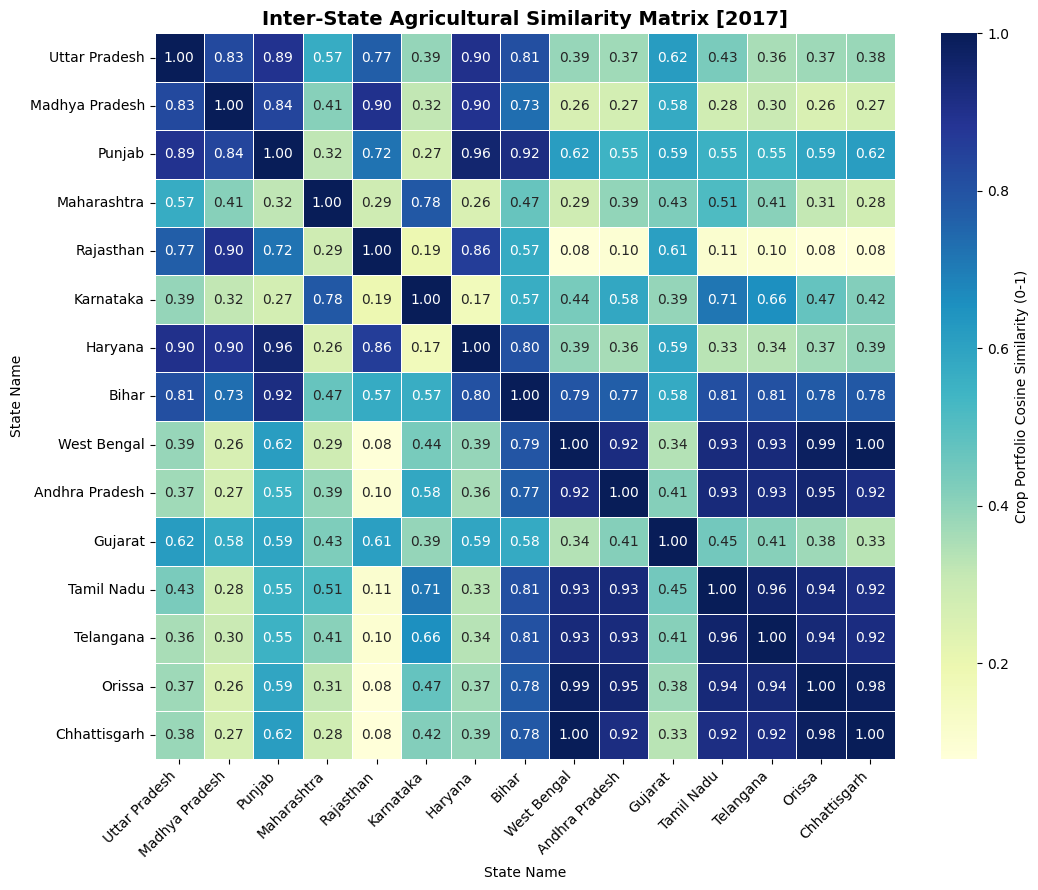

In [17]:
# ==========================================
# CELL 14: INTER-STATE PAIRWISE SIMILARITY HEATMAP
# ==========================================
plt.figure(figsize=(11, 9))

# Plot pairwise state similarity matrix generated from the PCA/Cosine pipeline
sns.heatmap(
    sim_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Crop Portfolio Cosine Similarity (0-1)'},
    linewidths=0.5
)

plt.title(f'Inter-State Agricultural Similarity Matrix [{recent_yr}]', fontsize=14, fontweight='bold')
plt.xlabel('State Name')
plt.ylabel('State Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()